# Self-Organizing Map (SOM)

## 1. Descripción

El algoritmo Self-Organizing Map (SOM) es un método de aprendizaje no supervisado que reduce datos de muchas variables a un mapa de dos dimensiones, manteniendo cercanas en el mapa a las observaciones similares en los datos originales. El mapa está compuesto por una cuadrícula de neuronas, donde cada neurona tiene asociado un vector de pesos con la misma dimensión que los datos de entrada.

Durante el entrenamiento, cada observación se compara contra todas las neuronas de la cuadrícula y se identifica la neurona ganadora, conocida como Best Matching Unit, que es aquella cuyo vector de pesos es más parecido a la observación. Los pesos de esa neurona y los de las neuronas vecinas dentro de un radio determinado se ajustan para parecerse más a la observación presentada. Este proceso se repite muchas veces, reduciendo poco a poco la tasa de aprendizaje y el radio de vecindad, hasta que el mapa queda organizado de forma que las observaciones parecidas terminan ubicadas en zonas cercanas de la cuadrícula.

### 1.1. Tipos de Entrada

Los tipos de datos que recibe deben ser variables numéricas continuas, ya que el algoritmo depende del cálculo de distancias entre los vectores de entrada y los vectores de pesos de las neuronas. Requiere que las variables estén en una escala comparable, aplicando normalización o estandarización cuando sea necesario.

### 1.2. Casos de Uso

El algoritmo SOM es adecuado cuando se busca reducir el número de variables de un conjunto de datos para poder verlo gráficamente, cuando se quieren agrupar observaciones sin conocer de antemano las categorías existentes y cuando se busca identificar las relaciones entre variables que no son evidentes en los datos originales.

Sus aplicaciones más comunes incluyen la visualización de datos con muchas variables, segmentación de clientes según patrones de comportamiento, detección de anomalías al identificar observaciones que no encajan en ninguna zona organizada del mapa y el análisis exploratorio de datos genómicos o financieros.


## 2. BibTeX y Referencias

@article{kohonen1982self,

  title={Self-organized formation of topologically correct feature maps},

  author={Kohonen, Teuvo},

  journal={Biological cybernetics},

  volume={43},

  number={1},

  pages={59--69},

  year={1982},

  publisher={Springer}

}

@article{kohonen1990self,

  title={The self-organizing map},

  author={Kohonen, Teuvo},

  journal={Proceedings of the IEEE},

  volume={78},

  number={9},

  pages={1464--1480},

  year={1990},

  publisher={IEEE}

}

@article{forest2020survey,

  title={A survey and implementation of performance metrics for self-organized maps},

  author={Forest, Florent and Lebbah, Mustapha and Azzag, Hanane and Lacaille, J{\'e}r{\^o}me},

  journal={arXiv preprint arXiv:2011.05847},

  year={2020}

}

## 3. Tipo de Modelo



* Método de Aprendizaje: aprendizaje no supervisado
* Por Parámetros: no paramétrico
* Datos de Aprendizaje: aprendizaje Online
* Resultado del Entrenamiento: basado en modelos





## 4. Algoritmo de Entrenamiento

Aprendizaje competitivo mediante la regla de Kohonen, en la cual las neuronas compiten por representar cada observación y solo la neurona ganadora junto con sus vecinas actualizan sus pesos en cada iteración.

## 5. Supuestos y Restricciones

* No paramétrico: no asume una distribución específica de los datos.
* No requiere linealidad: no asume una relación lineal entre las variables, por lo cual puede modelar relaciones no lineales entre ellas.
* Cercanía en el mapa: asume que las relaciones de cercanía entre los datos originales pueden representarse de forma razonable en un mapa de menor dimensión.
* Escala de las variables: requiere que las variables estén en una escala comparable, ya que el cálculo se basa en distancias.
* Sensibilidad a la inicialización: los resultados pueden variar según cómo se inicien los pesos de las neuronas.
* Definición de la cuadrícula: requiere definir de antemano el tamaño de la cuadrícula y la función de vecindad, decisiones que afectan directamente la calidad del mapa resultante.
* Costo computacional: el tiempo de entrenamiento crece con el número de neuronas y el número de iteraciones necesarias para que el mapa quede organizado.

## 6. Source Code de Self-Organizing Map (SOM)








### Librerías

In [ ]:
!pip install minisom

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from minisom import MiniSom

np.random.seed(42)

### Datos

In [ ]:
# Dataset Seeds (UCI): 210 muestras, 7 variables geométricas de granos de trigo, 3 variedades
columnas = ["area", "perimetro", "compacidad", "longitud_nucleo",
            "ancho_nucleo", "coef_asimetria", "longitud_surco", "variedad"]

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00236/seeds_dataset.txt"
df = pd.read_csv(url, sep=r"\s+", header=None, names=columnas)

X = df.drop(columns=["variedad"]).values
y = df["variedad"].values
feature_names = columnas[:-1]
class_names = ["Kama", "Rosa", "Canadian"]

df.head()

,area,perimetro,compacidad,longitud_nucleo,ancho_nucleo,coef_asimetria,longitud_surco,variedad
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


### Estandarización de Variables

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Entrenamiento del Modelo

In [ ]:
# Cuadrícula de 10x10 neuronas, entrenada sobre las 7 variables estandarizadas
som = MiniSom(x=10, y=10, input_len=X_scaled.shape[1], sigma=1.5, learning_rate=0.5, random_seed=42)
som.random_weights_init(X_scaled)
som.train_random(X_scaled, num_iteration=5000)

print("Entrenamiento completado")

Entrenamiento completado


### Visualización del Mapa (U-Matrix)

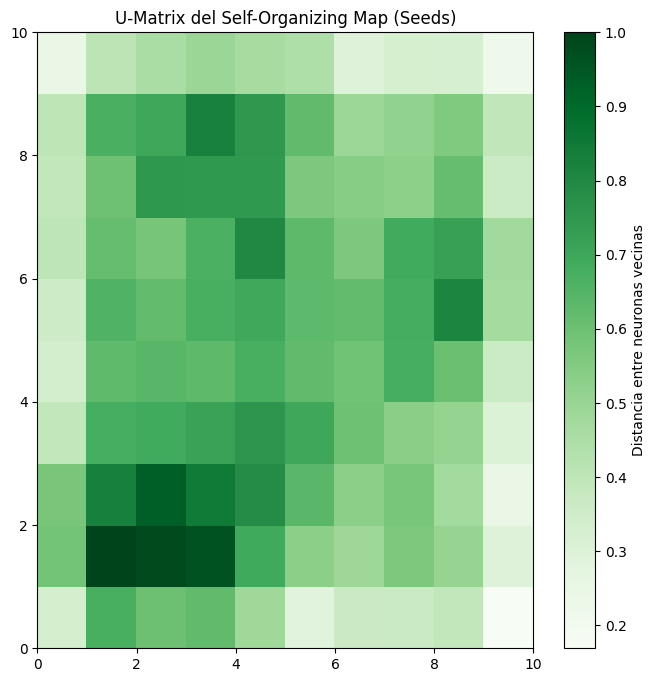

In [ ]:
plt.figure(figsize=(8, 8))
plt.pcolor(som.distance_map().T, cmap="Greens")
plt.colorbar(label="Distancia entre neuronas vecinas")
plt.title("U-Matrix del Self-Organizing Map (Seeds)")
plt.show()

### Mapeo de las Clases sobre el Mapa

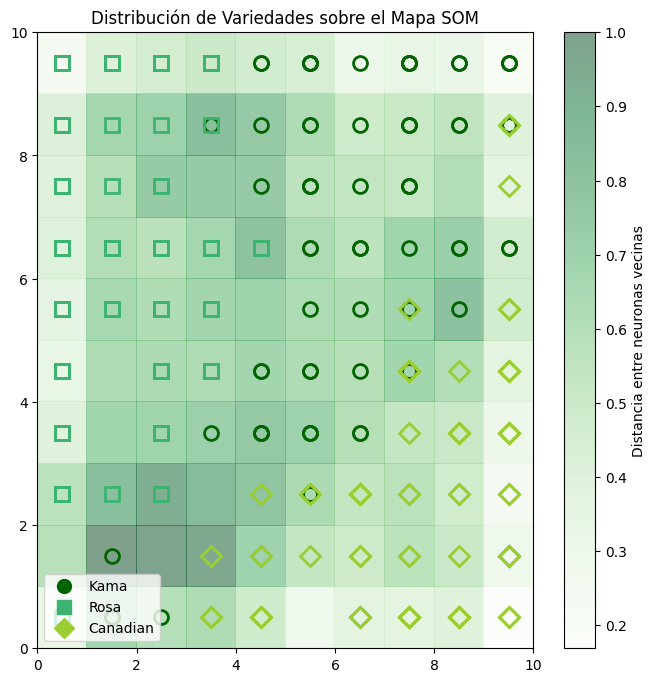

In [ ]:
plt.figure(figsize=(8, 8))
plt.pcolor(som.distance_map().T, cmap="Greens", alpha=0.5)
plt.colorbar(label="Distancia entre neuronas vecinas")

marcadores = ["o", "s", "D"]
colores = ["darkgreen", "mediumseagreen", "yellowgreen"]

for i, x in enumerate(X_scaled):
    w = som.winner(x)
    clase = y[i] - 1
    plt.plot(w[0] + 0.5, w[1] + 0.5, marcadores[clase],
             markerfacecolor="None", markeredgecolor=colores[clase],
             markersize=10, markeredgewidth=2)

handles = [plt.Line2D([0], [0], marker=marcadores[i], color=colores[i],
           linestyle="None", markersize=10, label=class_names[i]) for i in range(3)]
plt.legend(handles=handles)
plt.title("Distribución de Variedades sobre el Mapa SOM")
plt.show()

In [ ]:
# Métricas para evaluar la organización del mapa
from collections import Counter

# Error de cuantización, qué tan lejos están en promedio las observaciones de la neurona ganadora
qe = som.quantization_error(X_scaled)
print(f"Error de cuantización: {qe:.4f}")

# Para cada neurona ganadora, se revisa si las observaciones son de la misma variedad
neurona_variedades = {}
for i, x in enumerate(X_scaled):
    w = som.winner(x)
    neurona_variedades.setdefault(w, []).append(y[i])

neuronas_puras = sum(1 for v in neurona_variedades.values() if len(set(v)) == 1)
total_neuronas_usadas = len(neurona_variedades)

print(f"Neuronas activadas: {total_neuronas_usadas}")
print(f"Neuronas con una sola variedad (puras): {neuronas_puras}")
print(f"Porcentaje de neuronas puras: {neuronas_puras/total_neuronas_usadas*100:.1f}%")

Error de cuantización: 0.4139
Neuronas activadas: 91
Neuronas con una sola variedad (puras): 86
Porcentaje de neuronas puras: 94.5%


### Importancia de Variables por Neurona (Component Planes)

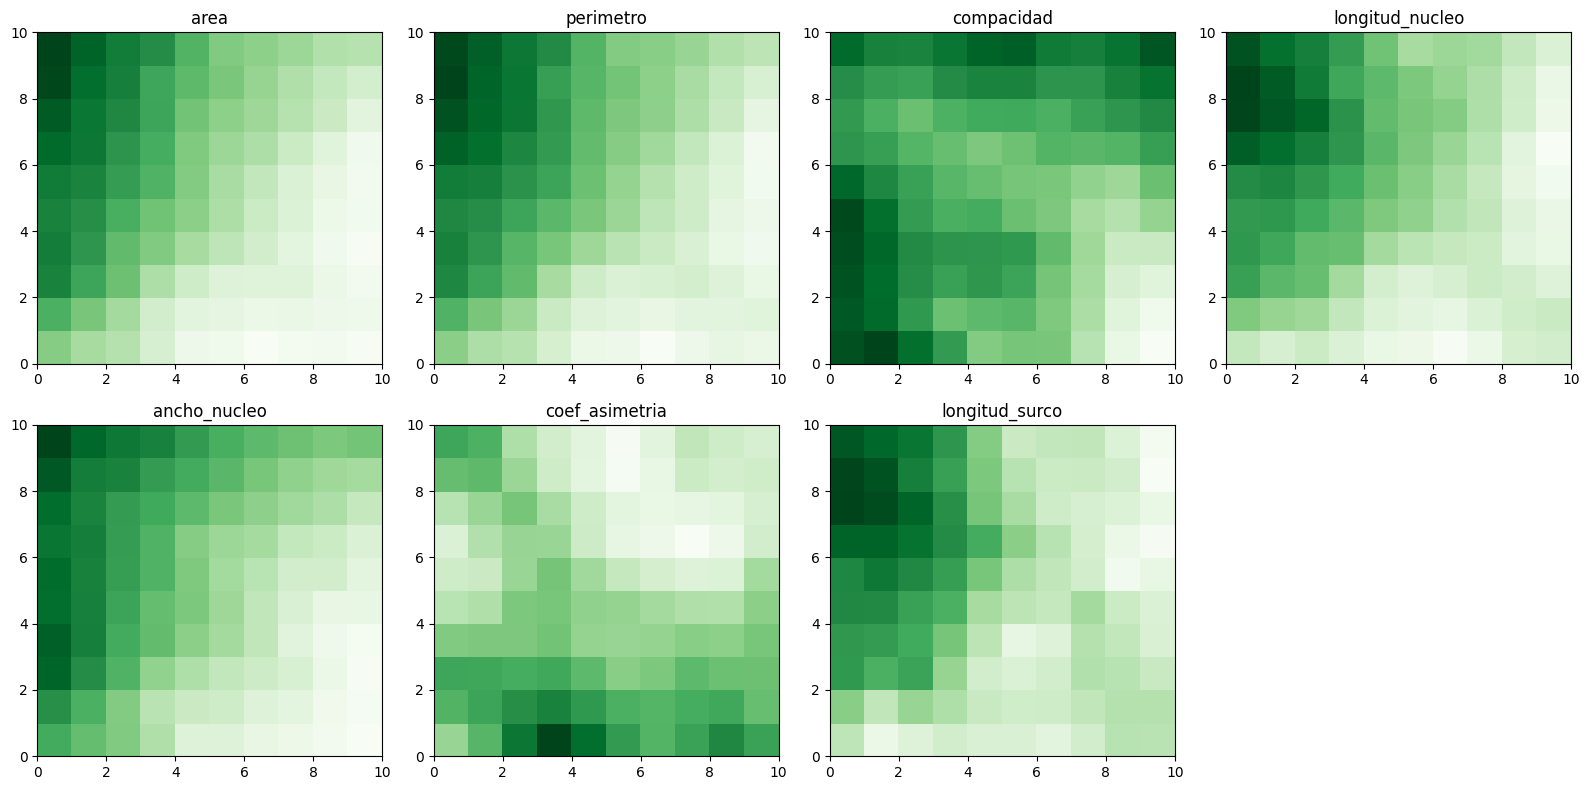

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for i, feature in enumerate(feature_names):
    plano = som.get_weights()[:, :, i]
    axes[i].pcolor(plano.T, cmap="Greens")
    axes[i].set_title(feature)

axes[-1].axis("off")
plt.tight_layout()
plt.show()

### Resultados

El mapa entrenado sobre el dataset Seeds obtuvo un error de cuantización de 0.4139, lo cual indica qué tan cerca están en promedio las observaciones de la neurona que las representa dentro de la cuadrícula.

De las 100 neuronas disponibles en la cuadrícula de 10x10, 91 fueron activadas por al menos una observación durante el entrenamiento. De esas 91 neuronas activadas, 86 resultaron puras, es decir que todas las observaciones que cayeron en esa neurona pertenecen a la misma variedad de trigo, lo cual representa un 94.5% de pureza. Esto indica que el mapa logró organizar el espacio de forma que las tres variedades quedaron mayormente separadas en regiones distintas de la cuadrícula, con muy poca mezcla entre ellas.